In [58]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.table import Table
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

import matplotlib.pyplot as plt

# Matplotlib configuration
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,           
    'ytick.right': True,         
    'xtick.minor.visible': True, 
    'ytick.minor.visible': True, 
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Pandas configuration
pd.set_option('display.max_columns', None)

# Paths configuration
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']
MAINPATH =  "/Users/jonginpark/sohnix/Research_Archive/2026/Park2026b-MACH-SMF"

%config InlineBackend.figure_format = 'retina'

In [88]:
# Define file paths
# mach_file = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_file = f"{MAINPATH}/DATA/MACH_PHOT/MACH_photcat_3R200.csv"
hecs_vac_file = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"

# Load datasets
mach_data = pd.read_csv(mach_file)
hecs_vac_data = pd.read_csv(hecs_vac_file)

# Apply extinction corrections
mach_data['cmodelMag_r_0'] = mach_data['cmodelMag_r'] - mach_data['extinction_r']
mach_data['cmodelMag_g_0'] = mach_data['cmodelMag_g'] - mach_data['extinction_g']

# Select only objects within R200
df = mach_data.loc[mach_data['Rcl/R200'] <= 3.0].copy()

In [101]:
# olddf = pd.read_csv('/Users/jonginpark/sohnix/Research_Archive/2026/04_MACH_SMF/DATA/MACH/MASTERCAT/MACH_DR18_within180_rawcat.csv')
# olddf['cmodelMag_r_0'] = olddf['cmodelMag_r'] - olddf['extinction_r']
# olddf['cmodelMag_g_0'] = olddf['cmodelMag_g'] - olddf['extinction_g']

# df_rip = df[['objid', 'cmodelMag_r_0', 'CLID', 'ra', 'dec', 'Z_TOT_Z', 'MEMBER']]
# olddf_rip = olddf[olddf['Z_TOT_Z']!=-99][['objid','cmodelMag_r_0', 'CLID', 'ra', 'dec', 'Z_TOT_Z', 'MEMBER']]
# df = pd.concat([df_rip, olddf_rip[~olddf_rip['objid'].isin(df_rip['objid'])]], ignore_index=True)

# 1. MACH Clusters Plot

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64253/3207127402.py:112: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  k = kde.gaussian_kde(kde_data, bw_method=0.12)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64253/3207127402.py:112: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  k = kde.gaussian_kde(kde_data, bw_method=0.12)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64253/3207127402.py:112: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  k = kde.gaussian_kde(kde_data, bw_method=0.12)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64253/3207127402.py:112: DeprecationWarning: Pl

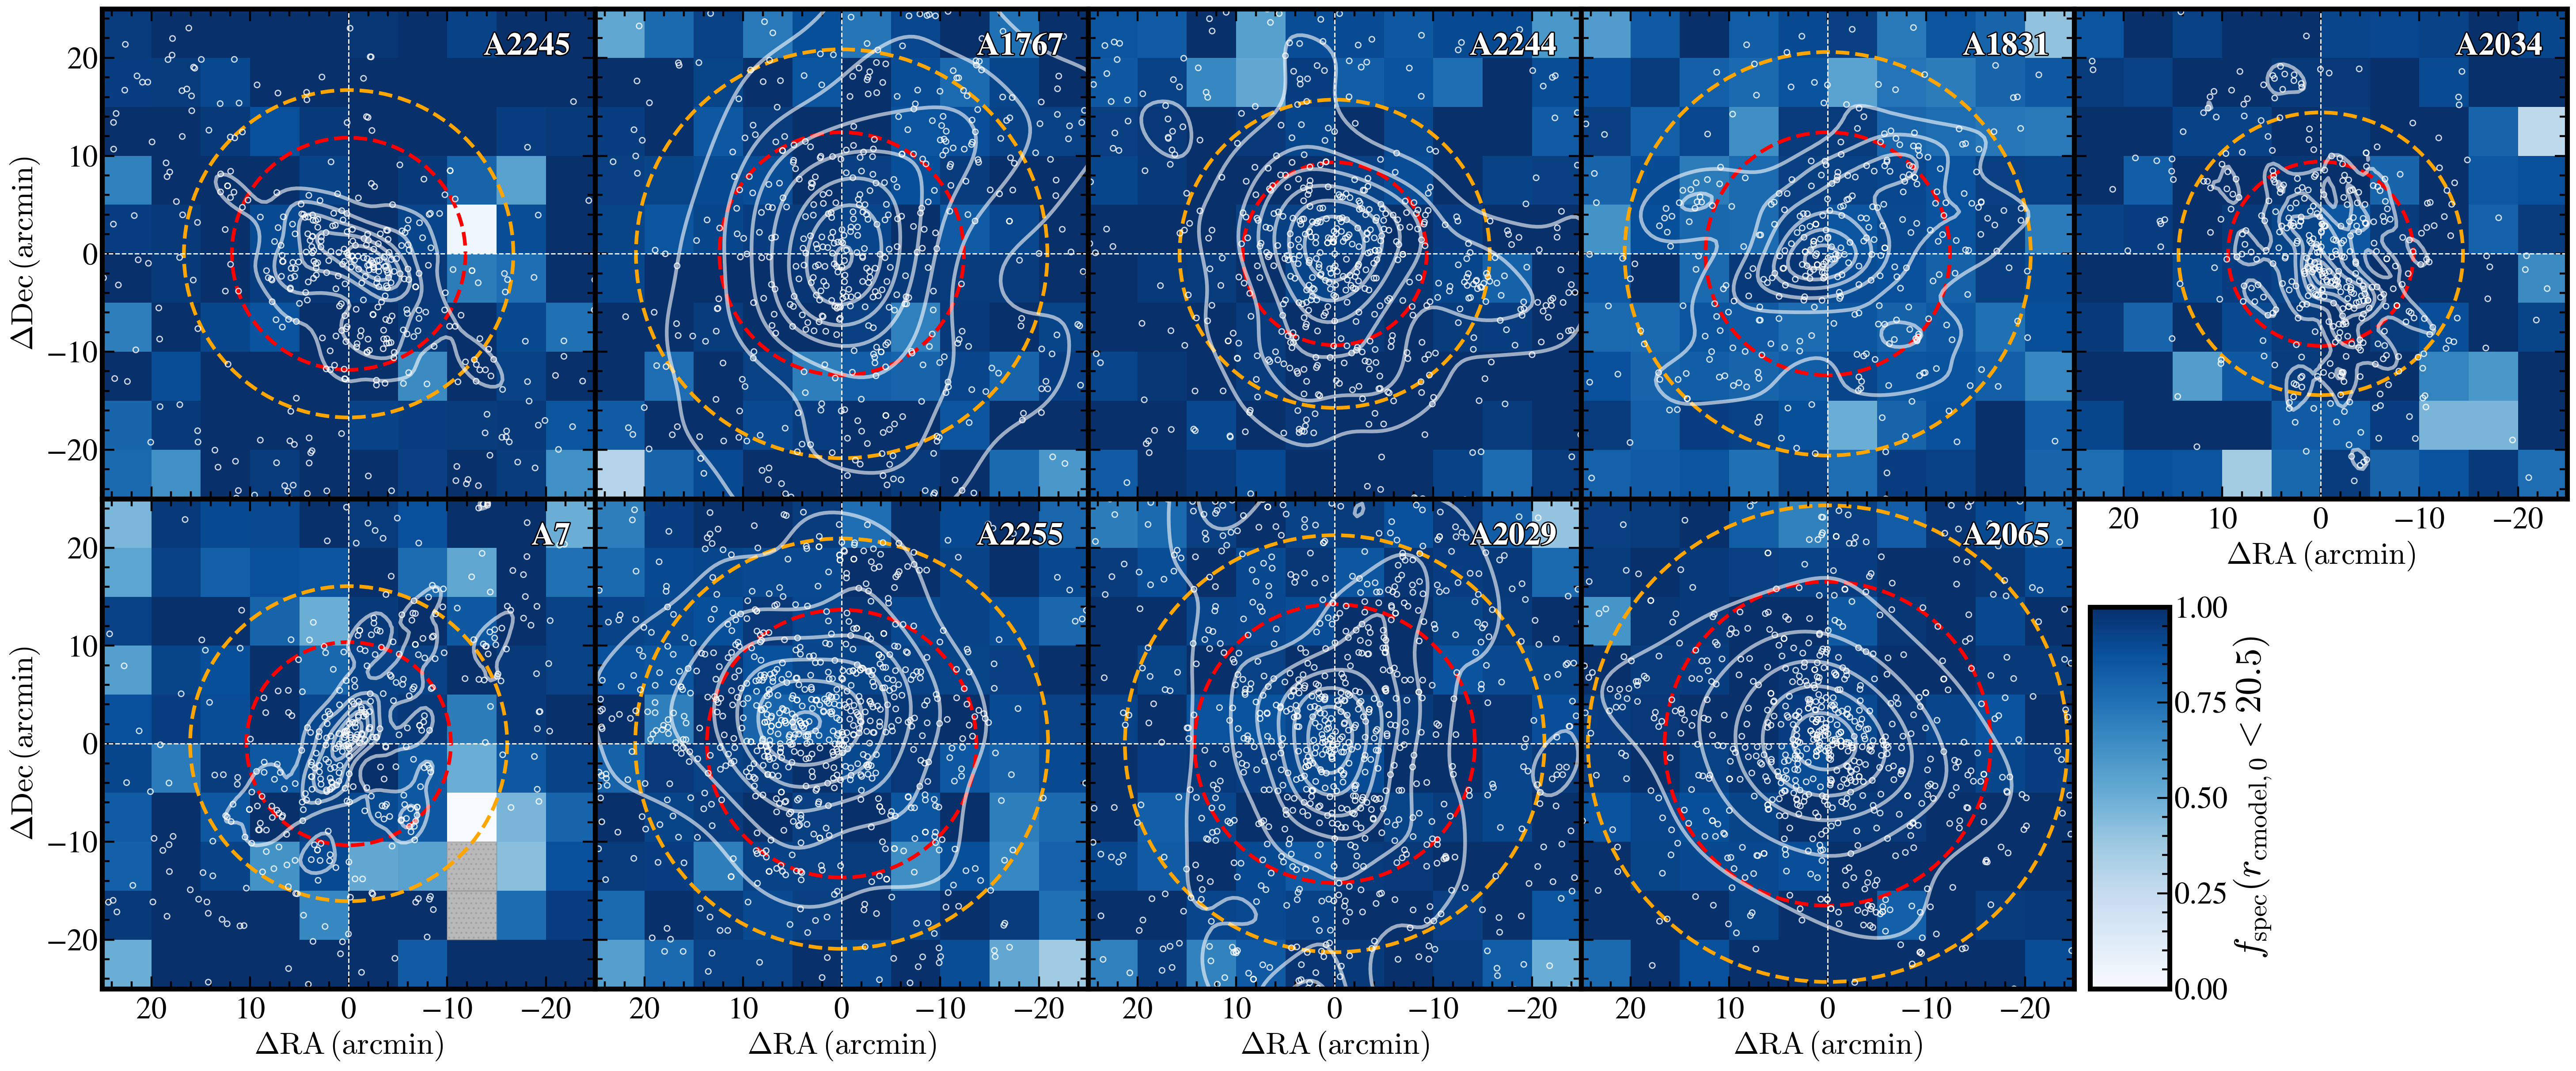

In [108]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
from scipy.stats import binned_statistic_2d
from scipy.stats import kde   # Deprecated, but maintained for current code compatibility
import pandas as pd

# ---- CONFIGURATION AND DATA PREP ----

# Prepare figure with 2 rows and 5 columns of subplots
fig, axs = plt.subplots(2, 5, figsize=(36, 14.4))
axs = axs.flatten()  # Flatten axes for 1D access

# Define plotting parameters
global_vmin = 0  # Minimum value for color scaling
global_vmax = 1  # Maximum value for color scaling
square_size = 5  # Bin size (arcminutes)

# Filter galaxies brighter than r_0 = 20.5
df_speccomp = df[df['cmodelMag_r_0'] < 20.5]

# ---- MAIN PLOTTING LOOP ----

# Loop through each target cluster in MACHLIST
for i, TARGET in enumerate(MACHLIST):

    # Filter for galaxies in the current cluster
    df_speccomp_target = df_speccomp[df_speccomp['CLID'] == TARGET]
    ra_values = df_speccomp_target['ra'].values
    dec_values = df_speccomp_target['dec'].values

    # Retrieve central properties for this cluster
    central_row = hecs_vac_data[hecs_vac_data['CLID'] == TARGET]
    central_ra = central_row['RA'].values[0]
    central_dec = central_row['DEC'].values[0]
    z = central_row['Z'].values[0]
    r200 = central_row['R200'].values[0]  # Mpc
    r500 = central_row['R500'].values[0]  # Mpc

    # Calculate physical scale: Mpc to arcmin
    d_a = cosmo.angular_diameter_distance(z).to(u.Mpc).value
    r200_arcmin = (r200 / d_a) * (180 / np.pi) * 60
    r500_arcmin = (r500 / d_a) * (180 / np.pi) * 60

    # Create SkyCoord objects for center and cluster galaxy positions
    central_coord = SkyCoord(ra=central_ra * u.degree, dec=central_dec * u.degree, frame='icrs')
    coords_all = SkyCoord(ra=ra_values * u.degree, dec=dec_values * u.degree, frame='icrs')

    # Calculate offset from cluster center in arcmin
    ra_diff_arcmin = (coords_all.ra.deg - central_coord.ra.deg) * np.cos(np.radians(central_coord.dec.deg)) * 60
    dec_diff_arcmin = (coords_all.dec.deg - central_coord.dec.deg) * 60

    # Create DataFrame with positions and spectroscopic flags
    df_member = pd.DataFrame({
        'RA_diff_arcmin': ra_diff_arcmin,
        'DEC_diff_arcmin': dec_diff_arcmin,
        'Z_TOT_Z': df_speccomp_target['Z_TOT_Z']
    })

    # Define 2D bin edges for histogram/grid
    ra_bins = np.arange(-25, 25 + square_size, square_size)
    dec_bins = np.arange(-25, 25 + square_size, square_size)

    # Compute spectroscopic fraction in each spatial bin
    spec_fraction, xedges, yedges, binnumber = binned_statistic_2d(
        df_member['RA_diff_arcmin'],
        df_member['DEC_diff_arcmin'],
        values=(df_member['Z_TOT_Z'] != -99).astype(int),   # 1 if has spectrum, 0 otherwise
        statistic='mean',
        bins=[ra_bins, dec_bins]
    )

    # -- MAIN PLOTTING --
    # Plot 2D completeness map with color mesh (gray for empty bins)
    masked_spec_fraction = np.ma.masked_invalid(spec_fraction.T)
    c = axs[i].pcolormesh(
        xedges, yedges, masked_spec_fraction,
        cmap='Blues', shading='auto', alpha=1.0,
        vmin=global_vmin, vmax=global_vmax
    )
    c.cmap.set_bad(color='lightgray', alpha=0.3)  # Visual cue for empty bins

    # Overlay hatched rectangles on empty bins
    for xi in range(len(xedges) - 1):
        for yi in range(len(yedges) - 1):
            if np.isnan(spec_fraction[xi, yi]):
                rect = plt.Rectangle(
                    (xedges[xi], yedges[yi]),
                    xedges[xi + 1] - xedges[xi],
                    yedges[yi + 1] - yedges[yi],
                    color='gray', alpha=0.3, hatch='...', edgecolor=None
                )
                axs[i].add_patch(rect)

    # Plot cluster member galaxies (MEMBER == 'Y') as open white circles
    df_members_y = df_speccomp_target[df_speccomp_target['MEMBER'] == 'Y']
    ra_members_y = df_members_y['ra'].values
    dec_members_y = df_members_y['dec'].values
    coords_members_y = SkyCoord(ra=ra_members_y * u.degree, dec=dec_members_y * u.degree, frame='icrs')
    ra_diff_members_y = (coords_members_y.ra.deg - central_coord.ra.deg) * np.cos(np.radians(central_coord.dec.deg)) * 60
    dec_diff_members_y = (coords_members_y.dec.deg - central_coord.dec.deg) * 60

    axs[i].scatter(
        ra_diff_members_y, dec_diff_members_y,
        marker='o', facecolors='none', edgecolors='white', alpha=0.8, zorder=2, s=20
    )

    # Plot KDE contours for density of cluster members ('Y')
    kde_data = np.vstack([ra_diff_members_y, dec_diff_members_y])
    k = kde.gaussian_kde(kde_data, bw_method=0.12)
    xi, yi = np.mgrid[ra_bins.min():ra_bins.max():100j, dec_bins.min():dec_bins.max():100j]
    zi = k(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    axs[i].contour(
        xi, yi, zi, levels=6, colors='white',
        linewidths=3, linestyles='solid', alpha=0.6
    )

    # Draw R200 and R500 circles around (0,0)
    circle_r200 = plt.Circle((0, 0), r200_arcmin, color='orange', linestyle='--', linewidth=3, fill=False)
    circle_r500 = plt.Circle((0, 0), r500_arcmin, color='red', linestyle='--', linewidth=3, fill=False)
    axs[i].add_artist(circle_r200)
    axs[i].add_artist(circle_r500)

    # Add white dashed axes cross (x=0 and y=0)
    axs[i].axhline(0, color='white', linestyle='--', linewidth=1)
    axs[i].axvline(0, color='white', linestyle='--', linewidth=1)

    # Axis label settings for subplot positions
    if i in [4, 5, 6, 7, 8, 9]:
        axs[i].set_xlabel(r'$\Delta \mathrm{RA} \, (\mathrm{arcmin})$')
    else:
        axs[i].set_xticklabels([])

    if i in [0, 5]:
        axs[i].set_ylabel(r'$\Delta \mathrm{Dec} \, (\mathrm{arcmin})$')
    else:
        axs[i].set_yticklabels([])

    # Fine-tuning (ticks, aspect, annotations)
    axs[i].minorticks_on()
    axs[i].tick_params(which='both', top=True, right=True)
    axs[i].set_xlim([-25, 25])
    axs[i].set_ylim([-25, 25])
    axs[i].invert_xaxis()
    axs[i].text(
        0.95, 0.95, f'{TARGET}', ha='right', va='top', transform=axs[i].transAxes, fontsize=26, fontweight='bold',
        color='white', path_effects=[patheffects.withStroke(linewidth=2, foreground="black")]
    )

# Hide any unused subplots (if number of clusters is less than 10)
if len(MACHLIST) < len(axs):
    for j in range(len(MACHLIST), len(axs)):
        axs[j].axis('off')

# Add color bar on the side, vertically
cbar_ax = fig.add_axes([0.750, 0.11, 0.025, 0.3])  # [left, bottom, width, height]
cbar = fig.colorbar(c, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'$f_{\mathrm{spec}}(r_\mathrm{cmodel,0}<20.5)$', fontsize=30)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])

# Remove space between subplots and save to file
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure3.pdf", format="pdf", bbox_inches="tight")
plt.show()


# 2. Single Cluster Plot (For Presentation showing)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_64253/2332516288.py:102: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  k = kde.gaussian_kde(kde_data, bw_method=0.15)


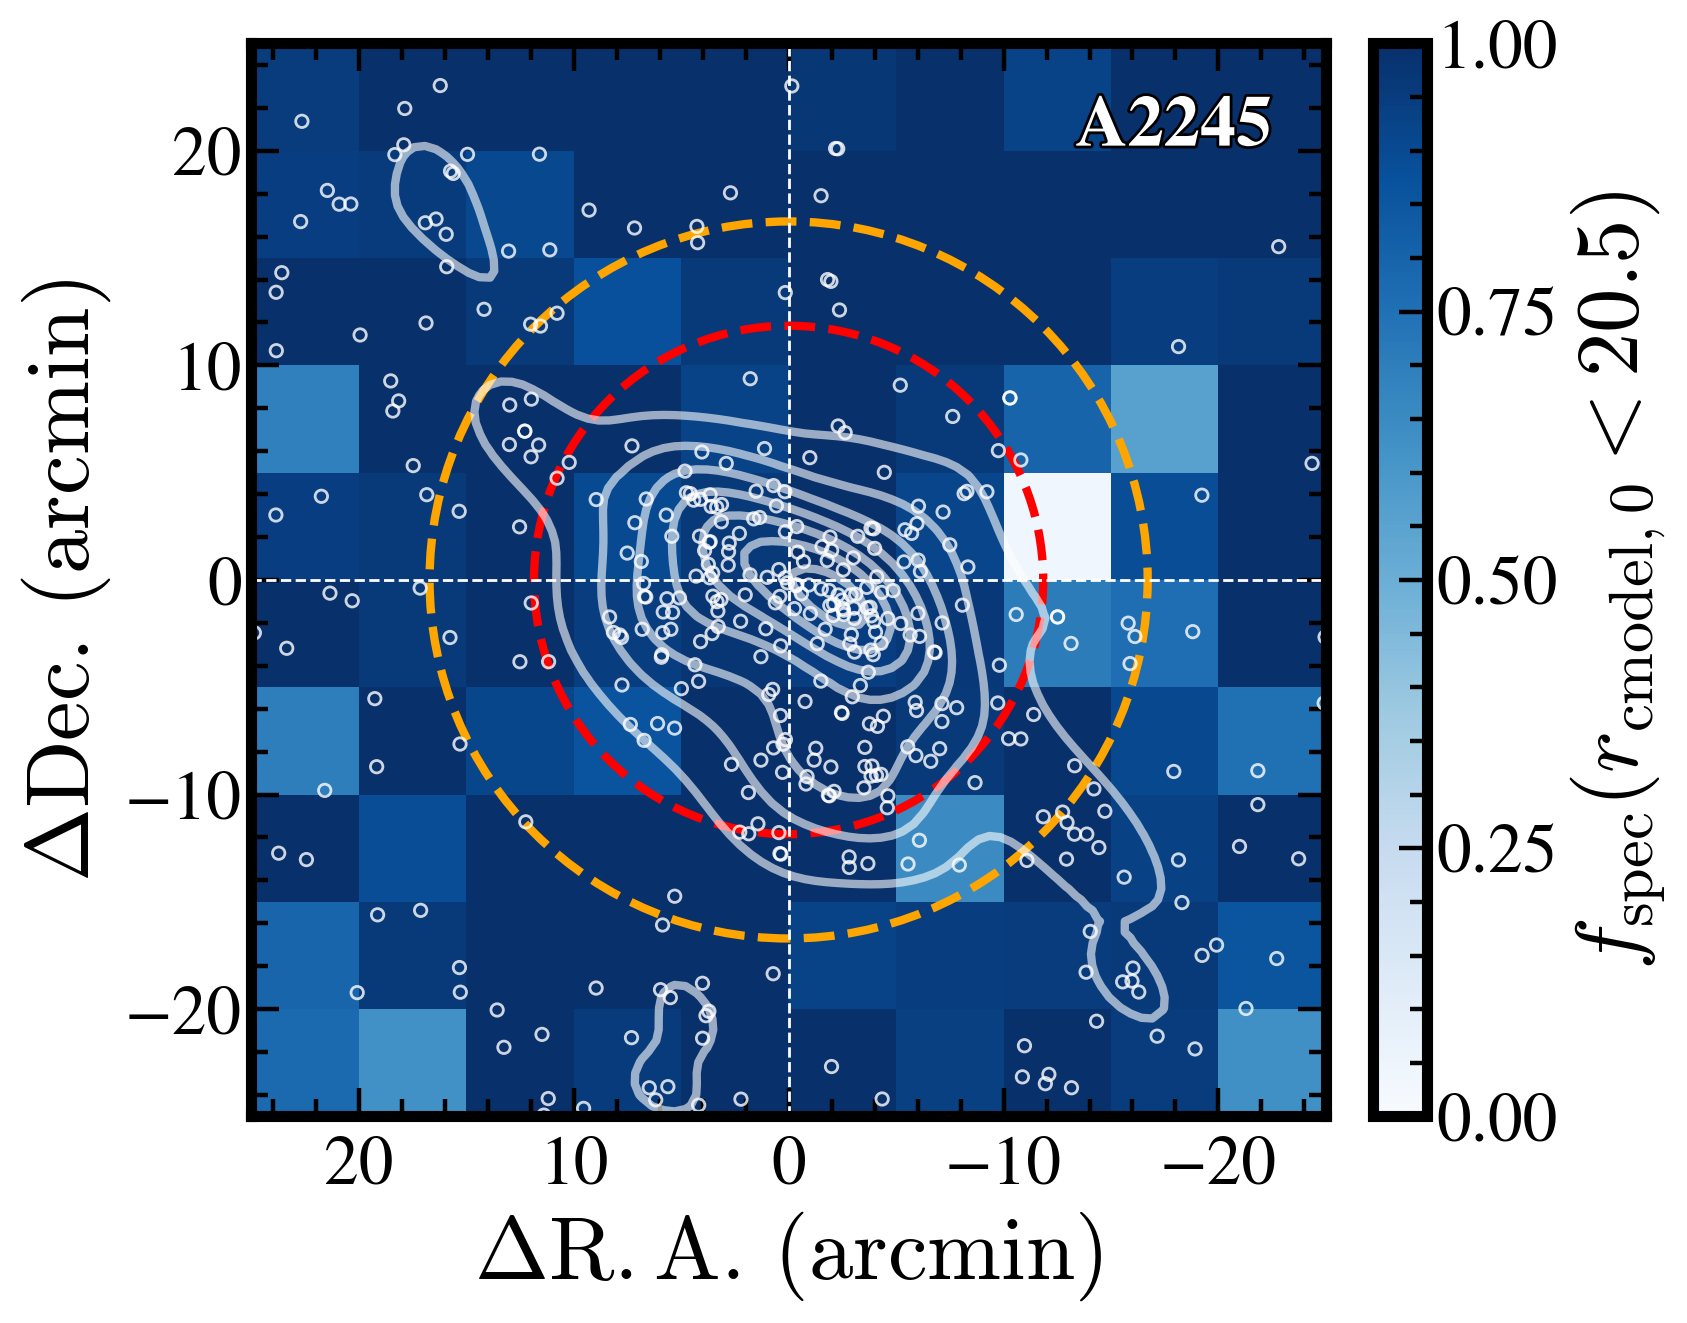

In [103]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
from scipy.stats import binned_statistic_2d
from scipy.stats import kde
import pandas as pd

# ----------------------------------------------------------------------------
# Plot the 2D spectroscopic completeness for a single cluster (TARGET)
# ----------------------------------------------------------------------------

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(9, 7.2))

# Set parameters
square_size = 5  # bin size in arcminutes
global_vmin, global_vmax = 0, 1  # range for color map
TARGET = 'A2245'

# Filter galaxies to those brighter than r=20.5
df_speccomp = df[df['cmodelMag_r_0'] < 20.5]

# Isolate only galaxies for this cluster
df_target = df_speccomp[df_speccomp['CLID'] == TARGET]
ra_vals = df_target['ra'].values
dec_vals = df_target['dec'].values

# Get cluster's center and physical scale info
central_row = hecs_vac_data[hecs_vac_data['CLID'] == TARGET]
central_ra = central_row['RA'].iloc[0]
central_dec = central_row['DEC'].iloc[0]
z = central_row['Z'].iloc[0]
r200 = central_row['R200'].iloc[0]       # [Mpc]
r500 = central_row['R500'].iloc[0]       # [Mpc]

# Compute the angular diameter distance at cluster redshift [Mpc]
d_a = cosmo.angular_diameter_distance(z).to(u.Mpc).value

# Convert radii from Mpc to arcmin for plotting
r200_arcmin = (r200 / d_a) * (180/np.pi) * 60
r500_arcmin = (r500 / d_a) * (180/np.pi) * 60

# Sky coordinates of center and all target members
coord_center = SkyCoord(central_ra * u.deg, central_dec * u.deg)
coord_all = SkyCoord(ra_vals * u.deg, dec_vals * u.deg)

# Compute RA and Dec offsets (in arcmin) from cluster center
ra_offset = (coord_all.ra.deg - coord_center.ra.deg) * np.cos(np.radians(central_dec)) * 60
dec_offset = (coord_all.dec.deg - coord_center.dec.deg) * 60

# Assemble new DataFrame with only relevant columns and computed offsets
df_member = pd.DataFrame({
    'RA_offset': ra_offset,
    'DEC_offset': dec_offset,
    'Z_TOT_Z': df_target['Z_TOT_Z'],
    'MEMBER': df_target['MEMBER']
})

# Bin edges for the 2d histogram
ra_bins = np.arange(-25, 25 + square_size, square_size)
dec_bins = np.arange(-25, 25 + square_size, square_size)

# Fraction of objects with spectroscopy in each bin
is_spec = (df_member['Z_TOT_Z'] != -99).astype(int)
spec_fraction, xedges, yedges, _ = binned_statistic_2d(
    df_member['RA_offset'], df_member['DEC_offset'],
    values=is_spec, statistic='mean', bins=[ra_bins, dec_bins]
)

# Plot heatmap of spec fraction (with masked NaNs)
c = ax.pcolormesh(
    xedges, yedges, np.ma.masked_invalid(spec_fraction.T),
    cmap='Blues', shading='auto', alpha=1.0, vmin=global_vmin, vmax=global_vmax
)
c.cmap.set_bad(color='lightgray', alpha=0.3)

# Dotted hatch for empty bins (spec_fraction nan)
for xi in range(len(xedges) - 1):
    for yi in range(len(yedges) - 1):
        if np.isnan(spec_fraction[xi, yi]):
            rect = plt.Rectangle(
                (xedges[xi], yedges[yi]),
                xedges[xi+1] - xedges[xi],
                yedges[yi+1] - yedges[yi],
                color='gray', alpha=0.3, hatch='...', edgecolor=None
            )
            ax.add_patch(rect)

# Overlay member galaxies (MEMBER=="Y") as open circles
df_member_y = df_member[df_member['MEMBER'] == 'Y']
ra_mem_y = df_member_y['RA_offset'].values
dec_mem_y = df_member_y['DEC_offset'].values
ax.scatter(
    ra_mem_y, dec_mem_y, marker='o', facecolors='none', edgecolors='white', alpha=0.8, zorder=2, s=20
)

# Overlay 2D KDE contour for member population
if len(ra_mem_y) > 1:
    kde_data = np.vstack([ra_mem_y, dec_mem_y])
    k = kde.gaussian_kde(kde_data, bw_method=0.15)
    xi, yi = np.mgrid[ra_bins.min():ra_bins.max():100j, dec_bins.min():dec_bins.max():100j]
    zi = k(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    ax.contour(
        xi, yi, zi, levels=8, colors='white', linewidths=3, linestyles='solid', alpha=0.6
    )

# Overplot R200 and R500 circles
circle_r200 = plt.Circle((0, 0), r200_arcmin, color='orange', linestyle='--', linewidth=3, fill=False)
circle_r500 = plt.Circle((0, 0), r500_arcmin, color='red', linestyle='--', linewidth=3, fill=False)
ax.add_artist(circle_r200)
ax.add_artist(circle_r500)

# Reference lines for center
ax.axhline(0, color='white', linestyle='--', linewidth=1)
ax.axvline(0, color='white', linestyle='--', linewidth=1)

# Labels, limits, and ticks
ax.set_xlabel(r'$\Delta \mathrm{R.A.} \, (\mathrm{arcmin})$', fontsize=32)
ax.set_ylabel(r'$\Delta \mathrm{Dec.} \, (\mathrm{arcmin})$', fontsize=32)
ax.minorticks_on()
ax.tick_params(which='both', top=True, right=True)
ax.set_xlim([-25, 25])
ax.set_ylim([-25, 25])
ax.invert_xaxis()

# Title annotation in upper right
ax.text(
    0.95, 0.95, f'{TARGET}',
    ha='right', va='top', transform=ax.transAxes, fontsize=26, fontweight='bold',
    color='white', path_effects=[patheffects.withStroke(linewidth=2, foreground="black")]
)

# Colorbar for completeness
cbar = fig.colorbar(c, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label(r'$f_{\mathrm{spec}}(r_\mathrm{cmodel,0}<20.5)$', fontsize=32)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])

# Layout and show
plt.tight_layout()
# plt.savefig(f"{FIGUREPATH}/A2065_2Dspec_completeness.pdf", format="pdf", bbox_inches="tight")
plt.show()